# Smartphone Regression

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os

## Merging Datasets

In [2]:
folderpath = (r"C:\Users\chukw\Documents\RAIN\AIML 1ST SEMESTER (File responses)\exam aiml 112")

In [3]:
os.listdir(folderpath)

['smartphone_battery_features.csv', 'smartphone_battery_targets.csv']

In [4]:
df= pd.DataFrame()
for filename in os.listdir(folderpath):
    dfs=pd.read_csv(fr"{folderpath}\{filename}")
    df = pd.concat([df,dfs], axis = 1)

In [5]:
df.head()

,Device_ID,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index,Device_ID,current_battery_health_percent,recommended_action
0,207dd94c-0430-43aa-b388-4893447e628e,38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,Medium,Poor,4,10.0,4.04,207dd94c-0430-43aa-b388-4893447e628e,32.8,Change Phone
1,3f4d1d33-ba89-4814-a168-7b4cc75be26b,28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,Medium,Good,7,10.0,4.23,3f4d1d33-ba89-4814-a168-7b4cc75be26b,50.3,Replace Battery
2,b4adca05-564f-4b70-ab69-e8d66e656463,14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,Medium,Good,6,10.0,2.21,b4adca05-564f-4b70-ab69-e8d66e656463,66.1,Replace Battery
3,4147e039-31b7-480a-bbc9-03cd0f66e9f1,42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,Medium,Good,8,10.0,3.13,4147e039-31b7-480a-bbc9-03cd0f66e9f1,46.8,Change Phone
4,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,High,Good,5,10.0,4.95,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,67.2,Replace Battery


## Dataset Probing and Cleaning

In [6]:
df.shape

(5000, 18)

In [7]:
df["recommended_action"].value_counts()

recommended_action
Replace Battery    2325
Keep Using         1440
Change Phone       1235
Name: count, dtype: int64

#### The dataset is balanced

In [8]:
df.isnull().sum()

Device_ID                           0
device_age_months                   0
battery_capacity_mah                0
avg_screen_on_hours_per_day         0
avg_charging_cycles_per_week        0
avg_battery_temp_celsius            0
fast_charging_usage_percent         0
overnight_charging_freq_per_week    0
gaming_hours_per_week               0
video_streaming_hours_per_week      0
background_app_usage_level          0
signal_strength_avg                 0
charging_habit_score                0
usage_intensity_score               0
thermal_stress_index                0
Device_ID                           0
current_battery_health_percent      0
recommended_action                  0
dtype: int64

#### There are no null values

In [9]:
df.dtypes

Device_ID                            object
device_age_months                     int64
battery_capacity_mah                  int64
avg_screen_on_hours_per_day         float64
avg_charging_cycles_per_week        float64
avg_battery_temp_celsius            float64
fast_charging_usage_percent         float64
overnight_charging_freq_per_week      int64
gaming_hours_per_week               float64
video_streaming_hours_per_week      float64
background_app_usage_level           object
signal_strength_avg                  object
charging_habit_score                  int64
usage_intensity_score               float64
thermal_stress_index                float64
Device_ID                            object
current_battery_health_percent      float64
recommended_action                   object
dtype: object

In [10]:
df=df.drop("Device_ID", axis=1)

In [11]:
df.head()

,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index,current_battery_health_percent,recommended_action
0,38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,Medium,Poor,4,10.0,4.04,32.8,Change Phone
1,28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,Medium,Good,7,10.0,4.23,50.3,Replace Battery
2,14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,Medium,Good,6,10.0,2.21,66.1,Replace Battery
3,42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,Medium,Good,8,10.0,3.13,46.8,Change Phone
4,7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,High,Good,5,10.0,4.95,67.2,Replace Battery


In [12]:
df.dtypes

device_age_months                     int64
battery_capacity_mah                  int64
avg_screen_on_hours_per_day         float64
avg_charging_cycles_per_week        float64
avg_battery_temp_celsius            float64
fast_charging_usage_percent         float64
overnight_charging_freq_per_week      int64
gaming_hours_per_week               float64
video_streaming_hours_per_week      float64
background_app_usage_level           object
signal_strength_avg                  object
charging_habit_score                  int64
usage_intensity_score               float64
thermal_stress_index                float64
current_battery_health_percent      float64
recommended_action                   object
dtype: object

## Using Encoding Techniques for background_app_usage_level,signal_strength_avg and recommended_action           

In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
encoder=LabelEncoder()

In [15]:
df["background_app_usage_level"] = encoder.fit_transform(df["background_app_usage_level"])
df["signal_strength_avg"]=encoder.fit_transform(df["signal_strength_avg"])
df["recommended_action"]=encoder.fit_transform(df["recommended_action"])

In [16]:
df.head()

,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index,current_battery_health_percent,recommended_action
0,38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,2,2,4,10.0,4.04,32.8,0
1,28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,2,0,7,10.0,4.23,50.3,2
2,14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,2,0,6,10.0,2.21,66.1,2
3,42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,2,0,8,10.0,3.13,46.8,0
4,7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,0,0,5,10.0,4.95,67.2,2


In [17]:
df.dtypes

device_age_months                     int64
battery_capacity_mah                  int64
avg_screen_on_hours_per_day         float64
avg_charging_cycles_per_week        float64
avg_battery_temp_celsius            float64
fast_charging_usage_percent         float64
overnight_charging_freq_per_week      int64
gaming_hours_per_week               float64
video_streaming_hours_per_week      float64
background_app_usage_level            int64
signal_strength_avg                   int64
charging_habit_score                  int64
usage_intensity_score               float64
thermal_stress_index                float64
current_battery_health_percent      float64
recommended_action                    int64
dtype: object

## Splitting the Data, using current_battery_health_percent as the dependent variable(y)

In [18]:
X=df.drop("current_battery_health_percent",axis=1)
y=df["current_battery_health_percent"]

In [19]:
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [20]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.15,random_state = 3 )

## Handling Outliers

In [21]:
X.describe()

,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index,recommended_action
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,24.232400,4134.700000,5.514120,8.33224,31.907360,50.712400,3.465200,4.012920,10.020740,1.015000,0.488200,6.582000,9.998394,3.079366,1.218000
std,14.138004,745.061698,1.974704,3.03454,2.544528,22.227398,2.306307,2.834289,4.990648,0.811484,0.660566,1.225225,0.058542,0.674274,0.815236
min,0.000000,3000.000000,1.000000,3.00000,21.600000,1.100000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,6.570000,1.000000,0.000000
25%,12.000000,4000.000000,4.200000,6.10000,30.200000,33.500000,1.000000,1.900000,6.600000,0.000000,0.000000,6.000000,10.000000,2.620000,1.000000
50%,24.000000,4500.000000,5.500000,8.25000,31.900000,51.000000,3.000000,3.300000,10.000000,1.000000,0.000000,7.000000,10.000000,3.070000,1.000000
75%,36.000000,5000.000000,6.900000,10.40000,33.600000,68.100000,5.000000,5.400000,13.400000,2.000000,1.000000,7.000000,10.000000,3.520000,2.000000
max,48.000000,5000.000000,12.000000,18.60000,41.200000,99.100000,7.000000,24.800000,27.200000,2.000000,2.000000,10.000000,10.000000,6.180000,2.000000


In [22]:
X.dtypes

device_age_months                     int64
battery_capacity_mah                  int64
avg_screen_on_hours_per_day         float64
avg_charging_cycles_per_week        float64
avg_battery_temp_celsius            float64
fast_charging_usage_percent         float64
overnight_charging_freq_per_week      int64
gaming_hours_per_week               float64
video_streaming_hours_per_week      float64
background_app_usage_level            int64
signal_strength_avg                   int64
charging_habit_score                  int64
usage_intensity_score               float64
thermal_stress_index                float64
recommended_action                    int64
dtype: object

<Axes: ylabel='device_age_months'>

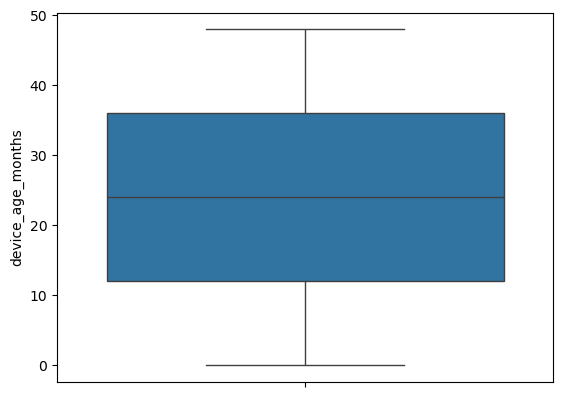

In [23]:
sns.boxplot(X["device_age_months"])

<Axes: ylabel='battery_capacity_mah'>

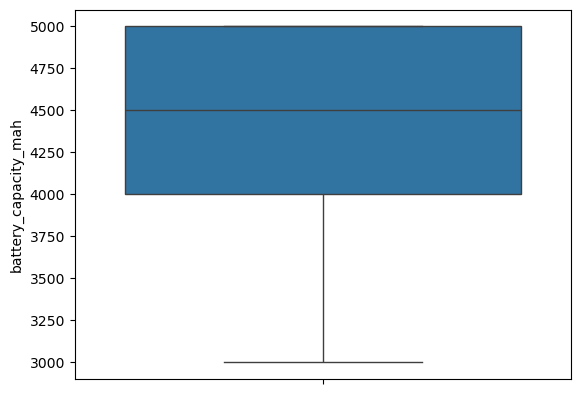

In [24]:
sns.boxplot(X["battery_capacity_mah"])

<Axes: ylabel='avg_screen_on_hours_per_day'>

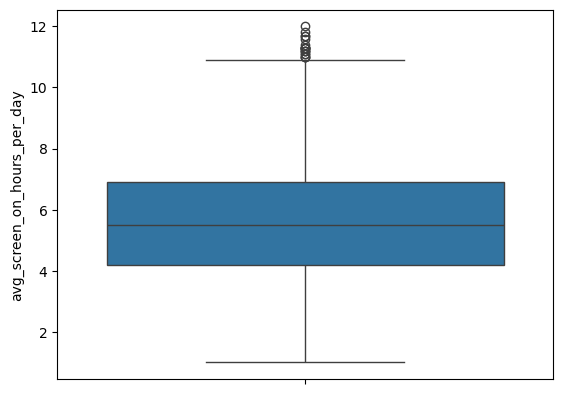

In [25]:
sns.boxplot(X["avg_screen_on_hours_per_day"])

<Axes: ylabel='avg_charging_cycles_per_week'>

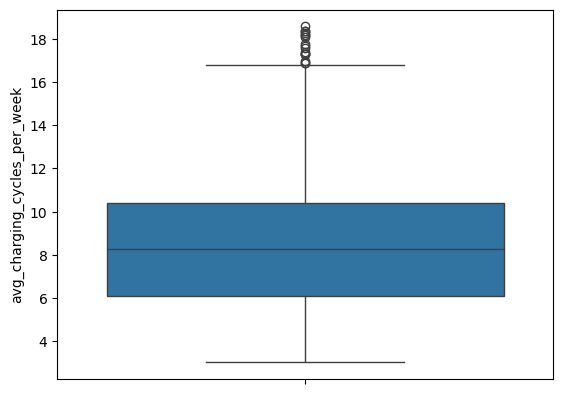

In [26]:
sns.boxplot(X["avg_charging_cycles_per_week"])

<Axes: ylabel='avg_battery_temp_celsius'>

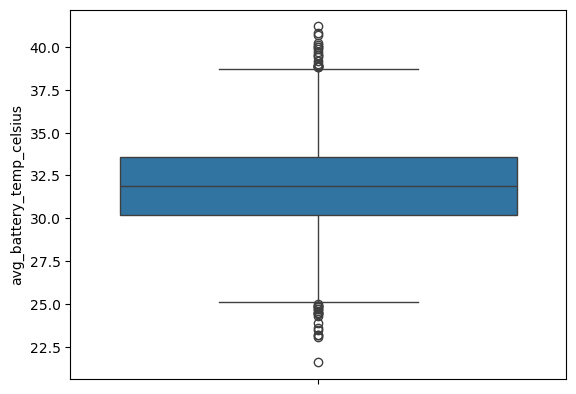

In [27]:
sns.boxplot(X["avg_battery_temp_celsius"])

<Axes: ylabel='fast_charging_usage_percent'>

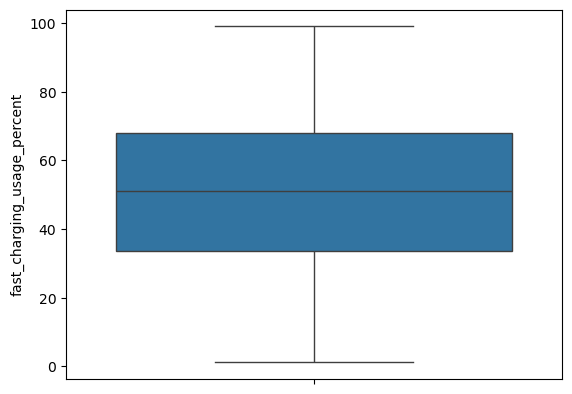

In [28]:
sns.boxplot(X["fast_charging_usage_percent"])

<Axes: ylabel='overnight_charging_freq_per_week'>

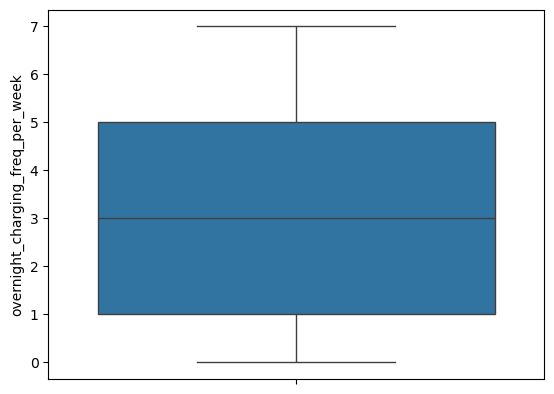

In [29]:
sns.boxplot(X["overnight_charging_freq_per_week"])

<Axes: ylabel='gaming_hours_per_week'>

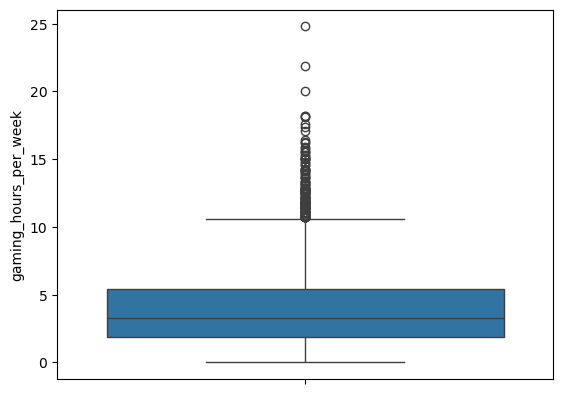

In [30]:
sns.boxplot(X["gaming_hours_per_week"])

<Axes: ylabel='video_streaming_hours_per_week'>

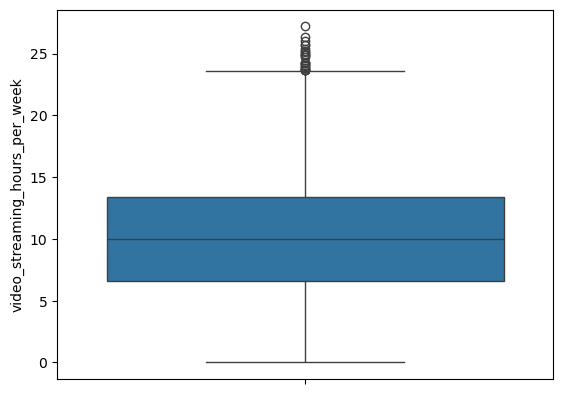

In [31]:
sns.boxplot(X["video_streaming_hours_per_week"])

<Axes: ylabel='background_app_usage_level'>

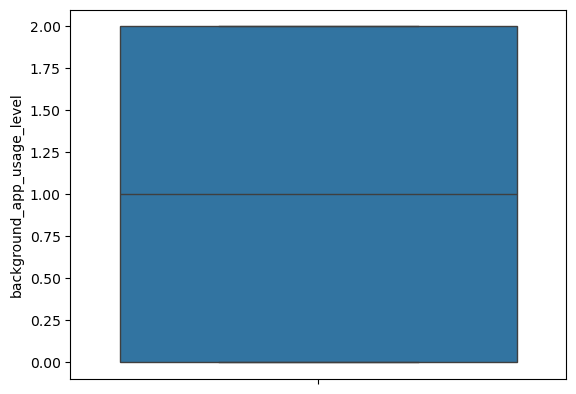

In [32]:
sns.boxplot(X["background_app_usage_level"])

<Axes: ylabel='signal_strength_avg'>

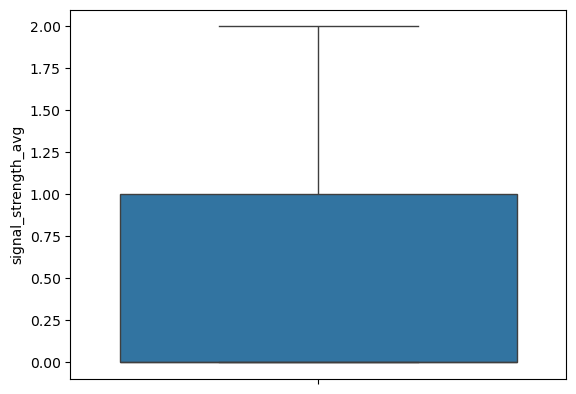

In [33]:
sns.boxplot(X["signal_strength_avg"])

<Axes: ylabel='charging_habit_score'>

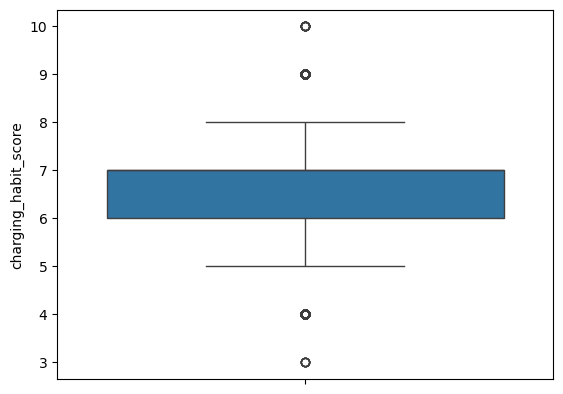

In [34]:
sns.boxplot(X["charging_habit_score"])

<Axes: ylabel='usage_intensity_score'>

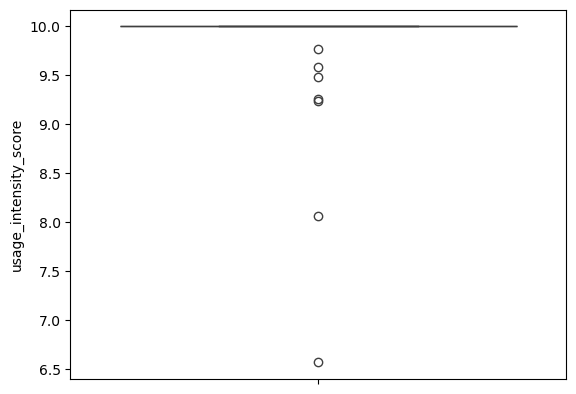

In [35]:
sns.boxplot(X["usage_intensity_score"])

<Axes: ylabel='thermal_stress_index'>

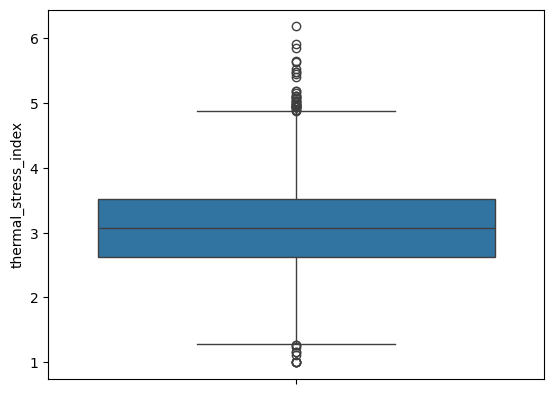

In [36]:
sns.boxplot(X["thermal_stress_index"])

In [38]:
#Using np.log
X_train["avg_screen_on_hours_per_day"]=np.log1p(X_train["avg_screen_on_hours_per_day"])
X_test["avg_screen_on_hours_per_day"]=np.log1p(X_test["avg_screen_on_hours_per_day"])

In [39]:
X_train["avg_charging_cycles_per_week"]=np.log1p(X_train["avg_charging_cycles_per_week"])
X_test["avg_charging_cycles_per_week"]=np.log1p(X_test["avg_charging_cycles_per_week"])

In [40]:
X_train["avg_battery_temp_celsius"]=np.log1p(X_train["avg_battery_temp_celsius"])
X_test["avg_battery_temp_celsius"]=np.log1p(X_test["avg_battery_temp_celsius"])

In [41]:
X_train["gaming_hours_per_week"]=np.log1p(X_train["gaming_hours_per_week"])
X_test["gaming_hours_per_week"]=np.log1p(X_test["gaming_hours_per_week"])

In [42]:
X_train["video_streaming_hours_per_week"]=np.log1p(X_train["video_streaming_hours_per_week"])
X_test["video_streaming_hours_per_week"]=np.log1p(X_test["video_streaming_hours_per_week"])

In [43]:
X_train["charging_habit_score"]=np.log1p(X_train["charging_habit_score"])
X_test["charging_habit_score"]=np.log1p(X_test["charging_habit_score"])

In [44]:
X_train["usage_intensity_score"]=np.log1p(X_train["usage_intensity_score"])
X_test["usage_intensity_score"]=np.log1p(X_test["usage_intensity_score"])

In [45]:
X_train["thermal_stress_index"]=np.log1p(X_train["thermal_stress_index"])
X_test["thermal_stress_index"]=np.log1p(X_test["thermal_stress_index"])

In [46]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("\nLinear Regression Results:")
print("R² score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Linear Regression Results:
R² score: 0.9374109067361643
MSE: 19.442808947487954
RMSE: 4.409400066617675


In [47]:
lasso = Lasso(alpha=0.1, random_state=3) 
lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_test)

print("\nLasso Regression Results:")
print("R² score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Lasso Regression Results:
R² score: 0.9333266124625623
MSE: 20.7115628006908
RMSE: 4.550995803194153


# The R² score is close to 1,so it fits the data very well.
# The MSE and RMSE is low, therefore the prediction are closer to the actual values.


## -------------------------------------------------------------------